# Chi-Squared Test

In our study of t-tests, we introduced the one-way t-test to check whether a sample mean differs from the an expected (population) mean. 

Lets consider another example, which is ***categorical***. 

## Chi-Squared Distribution

The chi-squared distribution is a continuous probability distribution that plays a crucial role in statistical inference, particularly in hypothesis testing and confidence interval construction. It is closely associated with the chi-squared statistic used in tests of independence and goodness of fit.

### Definition

The chi-squared distribution is a family of probability distributions, each determined by a parameter called the degrees of freedom.

Suppose $ X_1, X_2, \dots, X_k $ are independent and identically distributed variables from a normal (Gaussian) distribution with a mean of 0 and a variance of 1. The sum of the squares of these variables forms the chi-squared distribution:

$$
Q = \sum_{i=1}^{k} X_i^2
$$

This sum follows a chi-squared distribution with $ k $ degrees of freedom (df). The degrees of freedom determine the shape of the distribution: the more degrees of freedom, the more the distribution resembles a normal distribution.

The probability density function (PDF) of the chi-squared distribution is given by:

 $$f(x; k) = \frac{x^{(k/2 - 1)} e^{-x/2}}{2^{k/2} \Gamma(k/2)}$$

where $x$ is the random variable,
      $k$ is the degrees of freedom, 
      and $\Gamma$ is the gamma function.

### Characteristics

- **Shape and Symmetry:**
   - The chi-squared distribution is positively skewed and becomes more symmetric as the degrees of freedom increase.
   - As the degrees of freedom increase, the chi-squared distribution approaches a normal distribution.

- **Special Case:**
   - When \( k = 2 \), the chi-squared distribution is equivalent to the exponential distribution.

### Use in Statistical Testing

The chi-squared distribution is fundamental in hypothesis testing, particularly in the context of the chi-squared test for independence and the chi-squared goodness-of-fit test. It is also used in constructing confidence intervals for the variance of a normally distributed population.

### Critical Values

Tables of critical values are available for various significance levels and degrees of freedom. These tables are used to determine critical values for hypothesis testing. If the chi-squared statistic exceeds the critical value, we reject the null hypothesis. Otherwise, we fail to reject the null hypothesis.

### Applications

Common applications of the chi-squared distribution include testing the goodness of fit of an observed distribution to a theoretical distribution, testing independence in contingency tables, and estimating population variance.

In summary, the chi-squared distribution is a mathematical function that describes the probability of different outcomes in a chi-squared test. The shape of the distribution is determined by the degrees of freedom, and it is widely used in statistical analyses, especially when dealing with categorical data and hypothesis testing.

## Chi-Squared Goodness-Of-Fit Test: Example

### Hypothesis
- **Null Hypothesis (H₀):** There is no significant difference between the observed and expected frequencies of the categorical variable.
- **Alternative Hypothesis (H₁):** There is a significant difference between the observed and expected frequencies of the categorical variable.

### Data
Consider the following scenario where we are investigating the distribution of preferred colors in a population based on a survey. We have the following observed frequencies:

Observed table:
| Color  | Red | Blue | Green | Total |
|--------|-----|------|-------|-------|
| Observed | 30  | 40   | 30    | 100   |

### 1. Expected Frequencies:
   - Calculate the expected frequencies based on the expected distribution and the total number of observations.Once you have the assumed distribution, you calculate the expected frequencies for each category. This is done by multiplying the assumed proportion or probability of each category by the total number of observations.

Assuming the expected distribution:

| Color    | Red | Blue | Green |
|----------|-----|------|-------|
| Expected | 25% | 45%  | 30%   |


Assuming the expected frequency:

- Expected frequency for Red: $ 25\% \times 100 = 25 $
- Expected frequency for Blue: $ 45\% \times 100 = 45 $
- Expected frequency for Green: $ 30\% \times 100 = 30 $

 Expected table:
| Color | Red | Blue | Green | Total |
|-------|-----|------|-------|-------|
| Expected | 25 | 45 | 30 | 100 |

### 2. Chi-Squared Statistic:
   - Calculate the chi-squared statistic using the formula.

$$
\chi^2 = \sum \frac{(O_i - E_i)^2}{E_i}
$$

   For the example:

$$
\chi^2 = \frac{(30 - 25)^2}{25} + \frac{(40 - 45)^2}{45} + \frac{(30 - 30)^2}{30} \approx 2.67
$$

### 3. Degrees of Freedom:
   - The degrees of freedom in the goodness-of-fit test is equal to the number of categories minus 1.

$$
\text{Degrees of Freedom} = \text{Number of Categories} - 1
$$

   In this case,

$$
\text{Degrees of Freedom} = 3 - 1 = 2
$$

### 4. Critical Value or P-value:
   - Compare the chi-squared statistic to the critical value from the chi-squared distribution or calculate the p-value.
   - For a given significance level (e.g., 0.05), you can find the critical value from the chi-squared distribution table or use statistical software.

### Conclusion
- If the p-value is less than the significance level (e.g., 0.05), reject the null hypothesis.
- A significant result suggests that there is a significant difference between the observed and expected frequencies of the categorical variable.

In this example, with a calculated chi-squared statistic of approximately 2.67, you would compare this value to the critical value from the chi-squared distribution or calculate the p-value to make a conclusion about the distribution of preferred colors.

This test helps assess whether the observed frequencies match the expected frequencies based on a specified distribution. If the test is significant, it indicates a significant difference between observed and expected distributions.


**Once you know your degrees of freedom and your chosen significance level, you can look up the critical value in the Chi-Square distribution table.**

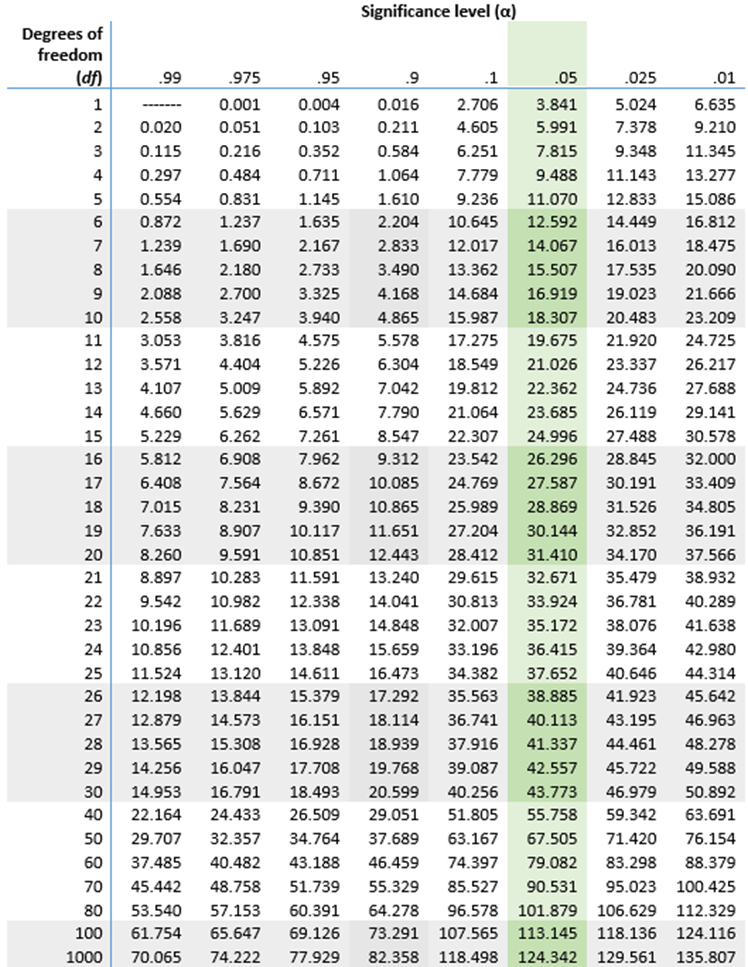

In [1]:
from IPython.display import display, Image
display(Image(filename ='chi-square-distribution-table.png'))

### Python example


Let's generate some fake demographic data for U.S. and Minnesota and walk through the chi-square goodness of fit test to check whether they are different

In [2]:
import numpy as np
import pandas as pd
import scipy.stats as stats

In [4]:
national = pd.DataFrame(["white"]*100000 + ["hispanic"]*60000 +\
                        ["african_american"]*50000 + ["asian"]*15000 + ["other"]*35000)
           

minnesota = pd.DataFrame(["white"]*600 + ["hispanic"]*300 + \
                         ["african_american"]*250 +["asian"]*75 + ["other"]*150)

national_table = pd.crosstab(index=national[0], columns="count")
minnesota_table = pd.crosstab(index=minnesota[0], columns="count")

print( "National")
print(national_table)
print(" ")
print( "Minnesota")
print(minnesota_table)

National
col_0              count
0                       
african_american   50000
asian              15000
hispanic           60000
other              35000
white             100000
 
Minnesota
col_0             count
0                      
african_american    250
asian                75
hispanic            300
other               150
white               600


In the formula, observed is the actual observed count for each category, and expected is the expected count based on the distribution of the population for the corresponding category. 

Let's calculate the chi-squared statistic for our data to illustrate:

In [5]:
observed = minnesota_table

national_ratios = national_table/len(national)  # Get population ratios

expected = national_ratios * len(minnesota)   # Get expected counts

chi_squared_stat = (((observed-expected)**2)/expected).sum()

print("Chi-Squared_Stat: %f" % float(chi_squared_stat.iloc[0]))

Chi-Squared_Stat: 18.194805


*Note: The chi-squared test assumes none of the expected counts are less than 5.

Similar to the t-test where we compared the t-test statistic to a critical value based on the t-distribution to determine whether the result is significant, in the chi-square test we compare the chi-square test statistic to a critical value based on the [chi-square distribution](https://en.wikipedia.org/wiki/Chi-squared_distribution). 

Chi-Squared PDF:

<center><img src="https://upload.wikimedia.org/wikipedia/commons/thumb/3/35/Chi-square_pdf.svg/1920px-Chi-square_pdf.svg.png" class="center" alt="Skewness" style="width: 900px;"/></center>

Chi-Squared CDF:

<center><img src="https://upload.wikimedia.org/wikipedia/commons/thumb/0/01/Chi-square_cdf.svg/1920px-Chi-square_cdf.svg.png" class="center" alt="Skewness" style="width: 900px;"/></center>



The scipy library shorthand for the chi-square distribution is `stats.chi2`. Let's use this knowledge to find the critical value for 95% confidence level and check the p-value of our result:

In [6]:
crit = stats.chi2.ppf(q = 0.95, # Find the critical value for 95% confidence*
                      df = 4)   # Df = number of variable categories - 1

print("Critical value")
print(crit)

p_value = 1 - stats.chi2.cdf(x=chi_squared_stat,  # Find the p-value
                             df=4)
print("P value")
print(p_value)

Critical value
9.487729036781154
P value
[0.00113047]


*Note: we are only interested in the right tail of the chi-square distribution. 

Since our chi-squared statistic exceeds the critical value, we'd ***reject the null hypothesis that the two distributions are the same.***

You can carry out a chi-squared goodness-of-fit test automatically using the scipy function `scipy.stats.chisquare()`:

In [9]:
stats.chisquare(f_obs= observed,   # Array of observed counts
                f_exp= expected)   # Array of expected counts

Power_divergenceResult(statistic=array([18.19480519]), pvalue=array([0.00113047]))

## Chi-Squared Test of Independence

[Independence](https://en.wikipedia.org/wiki/Independence_(probability_theory)) is a key concept in probability that describes a situation where ***knowing the value of one variable tells you nothing about the value of another.*** 

- For instance, the month you were born probably doesn't tell you anything which web browser you use, so we'd expect birth month and browser preference to be independent. 
    - On the other hand, your month of birth might be related to whether you excelled at sports in school, so month of birth and sports performance might not be independent.

The chi-squared test of independence ***tests whether two categorical variables are independent.*** 

- The test of independence is commonly used to determine whether variables like education, political views and other preferences vary based on demographic factors like gender, race and religion. 

### Chi-Squared Test for Independence: Example

#### Hypothesis
- **Null Hypothesis (H₀):** There is no significant association between gender and favorite color.
- **Alternative Hypothesis (H₁):** There is a significant association between gender and favorite color.

#### Data
Consider the following contingency table:

$$
\begin{array}{c|ccc}
\text{Gender / Color} & \text{Red} & \text{Blue} & \text{Green} \\
\hline
\text{Male} & 20 & 30 & 10 \\
\text{Female} & 15 & 25 & 20 \\
\end{array}
$$

#### Calculation of Chi-Squared Statistic

1. **Expected Frequencies:**
   - Calculate the row and column totals.
   
   $$
\begin{array}{c|ccc|c}
\text{Gender / Color} & \text{Red} & \text{Blue} & \text{Green} & \text{Row Total} \\
\hline
\text{Male} & 20 & 30 & 10 & 60 \\
\text{Female} & 15 & 25 & 20 & 60 \\
\hline
\text{Column Total} & 35 & 55 & 30 & 120 \\
\end{array}
$$
   
   - Calculate the expected frequency for each cell assuming no association.
   
    $$
    \text{Expected Frequency} = \frac{\text{Row Total} \times \text{Column Total}}{\text{Grand Total}}
    $$

    Calculation of Elements in Expected Table

- For Male and Red: $$\frac{60 \times 35}{120} = 17.50$$
- For Female and Red: $$\frac{60 \times 35}{120} = 17.50$$

- For Male and Blue: $$\frac{60 \times 55}{120} = 27.50$$
- For Female and Blue: $$\frac{60 \times 55}{120} = 27.50$$

- For Male and Green: $$\frac{60 \times 30}{120} = 15.00$$
- For Female and Green: $$\frac{60 \times 30}{120} = 15.00$$

- Expected table:
$$
\begin{array}{c|ccc|c}
\text{Gender / Color} & \text{Red} & \text{Blue} & \text{Green} & \text{Row Total} \\
\hline
\text{Male} & 17.50 & 27.50 & 15.00 & 60 \\
\text{Female} & 17.50 & 27.50 & 15.00 & 60 \\
\hline
\text{Column Total} & 35 & 55 & 30 & 120 \\
\end{array}
$$

2. **Chi-Squared Statistic:**
   - Calculate the chi-squared statistic using the formula.

$$
\chi^2 = \sum \frac{(O_{ij} - E_{ij})^2}{E_{ij}}
$$

    Where:
- $\chi^2$ is the chi-squared statistic.
- $O_{ij}$ is the observed frequency in cell (i, j) of the contingency table
- $E_{ij}$ is the expected frequency in cell (i, j) assuming independence.

    For the example:
$$
    \chi^2 = \frac{(20 - 17.50)^2}{17.50} + \frac{(15 - 17.50)^2}{17.50} + \frac{(30 - 27.50)^2}{27.50} + \frac{(25 - 27.50)^2}{27.50} + \frac{(10 - 15.00)^2}{15.00} + \frac{(20 - 15.00)^2}{15.00} \approx 6.28
$$

3. **Degrees of Freedom:**
   - For a 2x3 table, the degrees of freedom is $$(\text{rows} - 1) \times (\text{columns} - 1) = 1 \times 2 = 2.$$

4. **Critical Value or P-value:**
   - The chi-squared value is compared to a critical value from the chi-squared distribution or used to calculate a p-value. If the calculated chi-squared value is larger than the critical value or if the p-value is below a chosen significance level (e.g., 0.05), it suggests that the observed distribution is significantly different from what would be expected by chance alone. In this case, let's assume we find a p-value of 0.02.

#### Conclusion
- If the p-value is less than the significance level (e.g., 0.05), reject the null hypothesis.
- A significant result suggests that there is an association between gender and favorite color.

In this example, with a calculated chi-squared statistic of approximately 6.28 and assuming a p-value of 0.02, we would reject the null hypothesis and conclude that there is a significant association between gender and favorite color.


### Python example

Let's generate some fake voter polling data and perform a test of independence:

In [7]:
np.random.seed(10)

# Sample data randomly at fixed probabilities
voter_race = np.random.choice(a= ["asian","african_american","hispanic","other","white"],
                              p = [0.05, 0.15 ,0.25, 0.05, 0.5],
                              size=1000)

# Sample data randomly at fixed probabilities
voter_party = np.random.choice(a= ["democrat","independent","republican"],
                              p = [0.4, 0.2, 0.4],
                              size=1000)

voters = pd.DataFrame({"race":voter_race, 
                       "party":voter_party})
voters

,race,party
0,white,democrat
1,asian,republican
2,white,independent
3,white,republican
4,other,democrat
...,...,...
995,white,republican
996,hispanic,independent
997,african_american,independent
998,white,republican


In [8]:
voter_tab = pd.crosstab(voters.race, voters.party, margins = True)

voter_tab.columns = ["democrat","independent","republican","row_totals"]

voter_tab.index = ["asian","african_american","hispanic","other","white","col_totals"]

voter_tab

,democrat,independent,republican,row_totals
asian,65,25,64,154
african_american,21,7,32,60
hispanic,107,50,94,251
other,15,8,15,38
white,189,96,212,497
col_totals,397,186,417,1000


In [9]:
observed = voter_tab.iloc[0:5,0:3]   # Get table without totals for later use

In [10]:
observed

,democrat,independent,republican
asian,65,25,64
african_american,21,7,32
hispanic,107,50,94
other,15,8,15
white,189,96,212


In [11]:
expected =  np.outer(voter_tab["row_totals"][0:5],
                     voter_tab.loc["col_totals"][0:3]) / 1000

expected = pd.DataFrame(expected)

expected.columns = ["democrat","independent","republican"]
expected.index = ["asian","african_american","hispanic","other","white"]

expected

,democrat,independent,republican
asian,61.138,28.644,64.218
african_american,23.820,11.160,25.020
hispanic,99.647,46.686,104.667
other,15.086,7.068,15.846
white,197.309,92.442,207.249


Now we can follow the same steps we took before to calculate the chi-square statistic, the critical value and the p-value:

In [14]:
chi_squared_stat = (((observed-expected)**2)/expected).sum().sum()

print(chi_squared_stat)

7.169321280162059


*Note: We call `.sum()` twice: once to get the column sums and a second time to add the column sums together, returning the sum of the entire 2D table.

In [15]:
crit = stats.chi2.ppf(q = 0.95, # Find the critical value for 95% confidence*
                      df = 8)   # *

print("Critical value")
print(crit)

p_value = 1 - stats.chi2.cdf(x=chi_squared_stat,  # Find the p-value
                             df=8)
print("P value")
print(p_value)

Critical value
15.50731305586545
P value
0.518479392948842


*Note: The degrees of freedom for a test of independence equals the product of the number of categories in each variable minus 1. 
- In this case we have a 5x3 table so df = 4x2 = 8.


As with the goodness-of-fit test, we can use scipy to conduct a test of independence quickly. 
- Use `stats.chi2_contingency()` function to conduct a test of independence automatically given a frequency table of observed counts:

In [17]:
stats.chi2_contingency(observed = observed)

Chi2ContingencyResult(statistic=7.169321280162059, pvalue=0.518479392948842, dof=8, expected_freq=array([[ 61.138,  28.644,  64.218],
       [ 23.82 ,  11.16 ,  25.02 ],
       [ 99.647,  46.686, 104.667],
       [ 15.086,   7.068,  15.846],
       [197.309,  92.442, 207.249]]))

The output shows the chi-square statistic, the p-value and the degrees of freedom followed by the expected counts.

As expected, given the high p-value, ***the test result does not detect a significant relationship between the variables.***